# 06. Análisis de Consorcios — Estadísticas y Conclusiones Preliminares

Este notebook consolida las estadísticas descriptivas y los hallazgos preliminares sobre el subconjunto de contratos de obra pública adjudicados a consorcios (`es_grupo == 'Si'`), tras el cierre del pipeline desatendido de extracción de indicadores `pliego_*`.

## Insumos

- `data/contratos_depurado_modelo.parquet` — dataset depurado con `pliego_*` ya integrados (48,331 × 53)
- `../../data/resultados-final.json` — archivo final del pipeline Docker (7,994 registros)

## Objetivo

Documentar con evidencia cuantitativa el comportamiento histórico de los consorcios en la contratación pública de obra, evaluar la cobertura final de los indicadores extraídos y formular las conclusiones preliminares que orientarán la fase de evaluación y refinamiento del modelo predictivo.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

RAIZ_PROYECTO = Path('../..').resolve()
RAIZ_MODELO = Path('..').resolve()
DATA_RAW = RAIZ_PROYECTO / 'data'
FIGS = RAIZ_MODELO / 'figuras'
FIGS.mkdir(exist_ok=True)

print(f'Datos crudos: {DATA_RAW}')
print(f'Figuras out:  {FIGS}')

Datos crudos: C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos\data
Figuras out:  C:\Users\angel\OneDrive\Escritorio\trabajo dirigido\extraccion-datos\modelo-predictivo-preliminar\figuras


## 1. Carga de datos

In [2]:
df = pd.read_parquet(DATA_RAW / 'contratos_depurado_modelo.parquet')
print(f'Dataset completo: {df.shape}')

with open(DATA_RAW / 'resultados-final.json', encoding='utf-8') as f:
    resultados = json.load(f)
print(f'Resultados pipeline: {len(resultados):,} registros')

# Subconjunto consorcios
cons = df[df['es_grupo'] == 'Si'].copy()
no_cons = df[df['es_grupo'] == 'No'].copy()
print(f'\nConsorcios:    {len(cons):,}  ({len(cons)/len(df)*100:.1f}%)')
print(f'No consorcios: {len(no_cons):,}  ({len(no_cons)/len(df)*100:.1f}%)')

Dataset completo: (48331, 53)
Resultados pipeline: 7,994 registros

Consorcios:    10,629  (22.0%)
No consorcios: 37,702  (78.0%)


## 2. Resultados del pipeline desatendido de extracción

El pipeline Docker procesó los consorcios pendientes del periodo anterior. Cada contrato terminó con uno de los siguientes estados finales.

Distribución de estados finales del pipeline:
             estado    n       pct
                 ok 4276 53.490118
    sin_indicadores 2004 25.068802
error_irrecuperable 1621 20.277708
     sin_documentos   84  1.050788
           sin_pdfs    9  0.112584


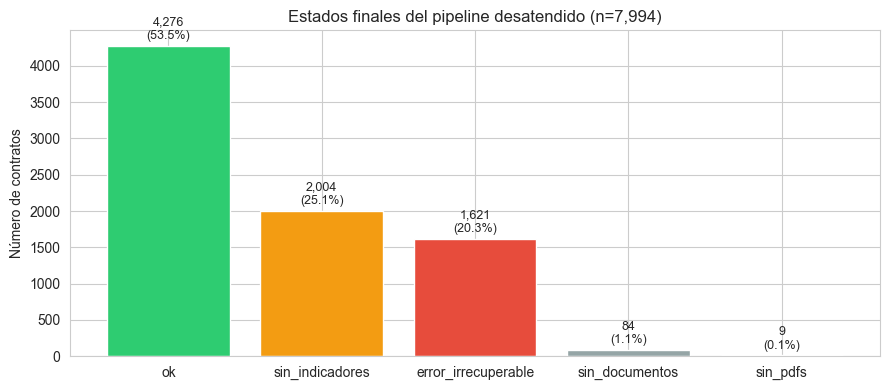

In [3]:
estados = Counter(r.get('estado', '?') for r in resultados)
df_estados = pd.DataFrame(estados.most_common(), columns=['estado', 'n'])
df_estados['pct'] = df_estados['n'] / df_estados['n'].sum() * 100
print('Distribución de estados finales del pipeline:')
print(df_estados.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = {'ok': '#2ecc71', 'sin_indicadores': '#f39c12', 'error_irrecuperable': '#e74c3c',
          'sin_documentos': '#95a5a6', 'sin_pdfs': '#7f8c8d'}
bars = ax.bar(df_estados['estado'], df_estados['n'],
               color=[colors.get(e, '#3498db') for e in df_estados['estado']])
for bar, n, pct in zip(bars, df_estados['n'], df_estados['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, n + 50,
            f'{n:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title(f'Estados finales del pipeline desatendido (n={len(resultados):,})')
ax.set_ylabel('Número de contratos')
plt.tight_layout()
plt.savefig(FIGS / 'dia_06_estados_pipeline.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Cobertura final de las variables `pliego_*` en consorcios

              indicador  n_consorcios  pct_consorcios  n_total  pct_total
           Liquidez mín          3877       36.475680     3877   8.021767
    Endeudamiento máx %          3858       36.296924     3858   7.982454
Cobertura intereses mín          3666       34.490545     3666   7.585194
              ROE mín %          3691       34.725750     3691   7.636920
              ROA mín %          3676       34.584627     3676   7.605884
      Capital trabajo %          1367       12.861041     1367   2.828412


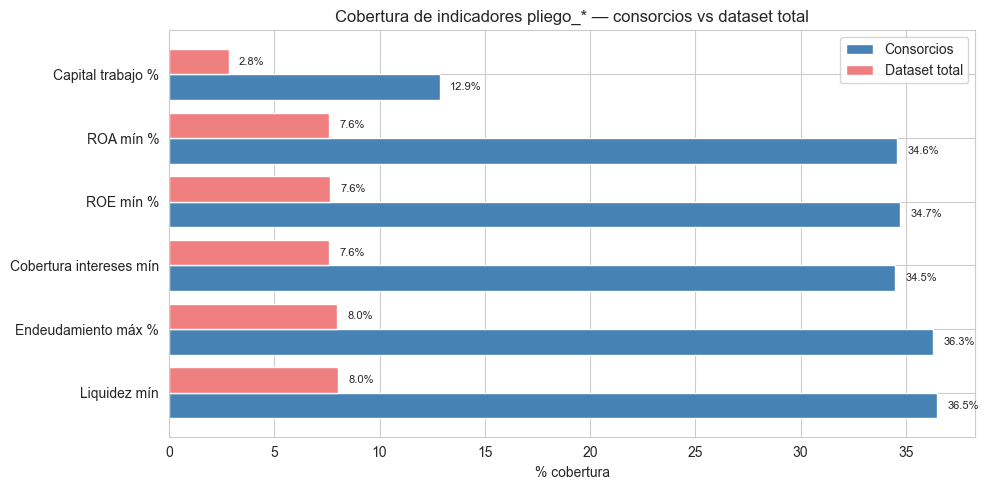

In [4]:
INDS_PLIEGO = [
    'pliego_liquidez_min',
    'pliego_endeudamiento_max_pct',
    'pliego_cobertura_intereses_min',
    'pliego_rentabilidad_patrimonio_min_pct',
    'pliego_rentabilidad_activo_min_pct',
    'pliego_capital_trabajo_min_pct_presupuesto',
]
LABELS = {
    'pliego_liquidez_min': 'Liquidez mín',
    'pliego_endeudamiento_max_pct': 'Endeudamiento máx %',
    'pliego_cobertura_intereses_min': 'Cobertura intereses mín',
    'pliego_rentabilidad_patrimonio_min_pct': 'ROE mín %',
    'pliego_rentabilidad_activo_min_pct': 'ROA mín %',
    'pliego_capital_trabajo_min_pct_presupuesto': 'Capital trabajo %',
}

filas = []
for c in INDS_PLIEGO:
    n_cons = cons[c].notna().sum()
    n_tot = df[c].notna().sum()
    filas.append({
        'indicador': LABELS[c],
        'n_consorcios': n_cons,
        'pct_consorcios': n_cons / len(cons) * 100,
        'n_total': n_tot,
        'pct_total': n_tot / len(df) * 100,
    })
df_cob = pd.DataFrame(filas)
print(df_cob.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_cob))
w = 0.4
ax.barh(x - w/2, df_cob['pct_consorcios'], w, label='Consorcios', color='steelblue')
ax.barh(x + w/2, df_cob['pct_total'], w, label='Dataset total', color='lightcoral')
for i, (vc, vt) in enumerate(zip(df_cob['pct_consorcios'], df_cob['pct_total'])):
    ax.text(vc + 0.5, i - w/2, f'{vc:.1f}%', va='center', fontsize=8)
    ax.text(vt + 0.5, i + w/2, f'{vt:.1f}%', va='center', fontsize=8)
ax.set_yticks(x)
ax.set_yticklabels(df_cob['indicador'])
ax.set_xlabel('% cobertura')
ax.set_title('Cobertura de indicadores pliego_* — consorcios vs dataset total')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'dia_06_cobertura_pliego.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Tasas de modificación: consorcios vs no consorcios

Comparamos las tres dimensiones de modificación contractual (`tiempo`, `presupuesto`, `alcance`) entre consorcios y no consorcios.

Tasas (% positivos):
                          Consorcios  No consorcios  Total
Atraso (tiempo)                44.63          64.95  60.48
Sobrecosto (presupuesto)       77.89          84.96  83.41
Cambio de alcance              93.49          97.33  96.49


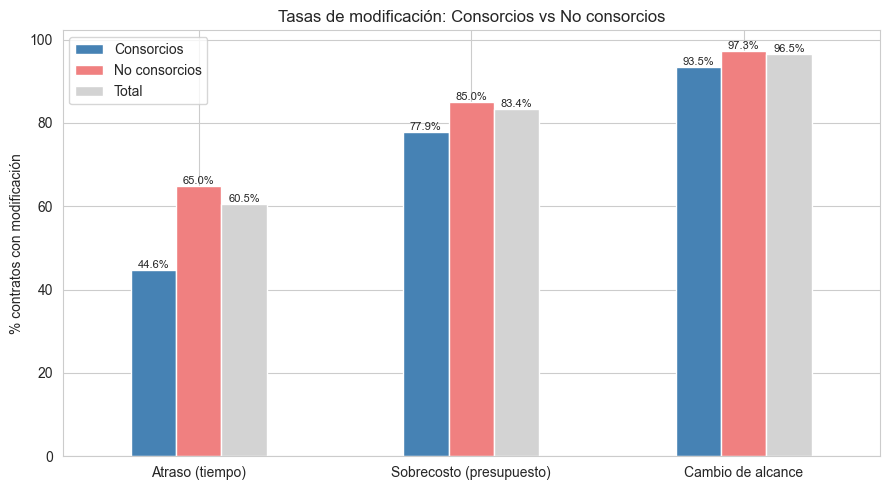

In [5]:
tasas = pd.DataFrame({
    'Consorcios': [cons['tiempo'].mean() * 100, cons['presupuesto'].mean() * 100, cons['alcance'].mean() * 100],
    'No consorcios': [no_cons['tiempo'].mean() * 100, no_cons['presupuesto'].mean() * 100, no_cons['alcance'].mean() * 100],
    'Total': [df['tiempo'].mean() * 100, df['presupuesto'].mean() * 100, df['alcance'].mean() * 100],
}, index=['Atraso (tiempo)', 'Sobrecosto (presupuesto)', 'Cambio de alcance'])
print('Tasas (% positivos):')
print(tasas.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
tasas.plot(kind='bar', ax=ax, color=['steelblue', 'lightcoral', 'lightgray'])
ax.set_ylabel('% contratos con modificación')
ax.set_title('Tasas de modificación: Consorcios vs No consorcios')
ax.set_xticklabels(tasas.index, rotation=0)
ax.legend(loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'dia_06_tasas_modificacion.png', dpi=120, bbox_inches='tight')
plt.show()

**Hallazgo 1**: los consorcios presentan tasas significativamente menores de atraso (-15.9 pp) y de sobrecosto (-5.5 pp) que los contratos no asociados a consorcios. Esto puede deberse a que los consorcios suelen tener mayor capacidad organizacional y financiera al combinar recursos de varias empresas.

## 5. Distribución de valor y duración de contratos de consorcios

Estadísticas de valor del contrato (COP):
                 Consorcios       No consorcios
mediana      $1,542,231,047        $110,469,185
p25            $478,827,221         $40,000,000
p75          $5,686,603,524        $429,560,192
max      $1,151,851,315,885  $7,127,629,832,600


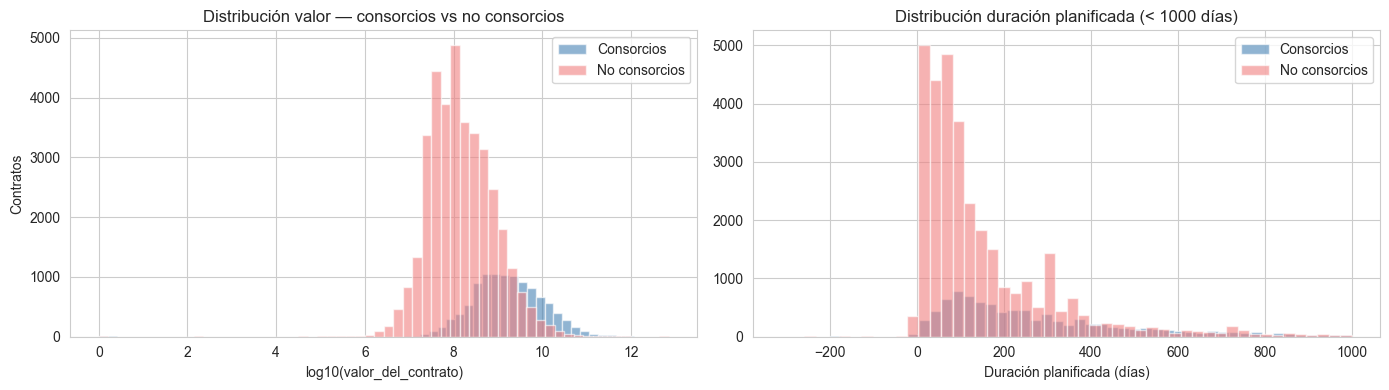

In [6]:
v_c = cons['valor_del_contrato']
v_n = no_cons['valor_del_contrato']
stats_v = pd.DataFrame({
    'Consorcios': [v_c.median(), v_c.quantile(0.25), v_c.quantile(0.75), v_c.max()],
    'No consorcios': [v_n.median(), v_n.quantile(0.25), v_n.quantile(0.75), v_n.max()],
}, index=['mediana', 'p25', 'p75', 'max'])
print('Estadísticas de valor del contrato (COP):')
print(stats_v.apply(lambda c: c.map(lambda x: f'${x:,.0f}')).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for sub, color, label in [(v_c, 'steelblue', 'Consorcios'), (v_n, 'lightcoral', 'No consorcios')]:
    sub_log = np.log10(sub[sub > 0])
    axes[0].hist(sub_log, bins=60, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('log10(valor_del_contrato)')
axes[0].set_ylabel('Contratos')
axes[0].set_title('Distribución valor — consorcios vs no consorcios')
axes[0].legend()

# Duración
d_c = cons['duracion_planificada_dias'].dropna()
d_n = no_cons['duracion_planificada_dias'].dropna()
axes[1].hist(d_c[d_c < 1000], bins=50, alpha=0.6, label='Consorcios', color='steelblue')
axes[1].hist(d_n[d_n < 1000], bins=50, alpha=0.6, label='No consorcios', color='lightcoral')
axes[1].set_xlabel('Duración planificada (días)')
axes[1].set_title('Distribución duración planificada (< 1000 días)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGS / 'dia_06_valor_duracion.png', dpi=120, bbox_inches='tight')
plt.show()

**Hallazgo 2**: los consorcios concentran contratos de mayor valor (mediana ≈ $1.5 B vs no consorcios mediana ≈ $200-300 M), lo cual es consistente con el hecho de que la unión de varias empresas se hace, principalmente, para acceder a contratos grandes que exceden la capacidad financiera individual.

## 6. Modalidad de contratación más usada por consorcios

In [7]:
modal_c = cons['modalidad_de_contratacion'].value_counts()
modal_c_pct = (modal_c / len(cons) * 100).round(1)

modal_n = no_cons['modalidad_de_contratacion'].value_counts()
modal_n_pct = (modal_n / len(no_cons) * 100).round(1)

comp = pd.DataFrame({
    'Consorcios n': modal_c.head(8),
    'Consorcios %': modal_c_pct.head(8),
    'No consorcios n': modal_n.reindex(modal_c.head(8).index, fill_value=0),
    'No consorcios %': modal_n_pct.reindex(modal_c.head(8).index, fill_value=0),
})
print('Modalidades más frecuentes en consorcios:')
print(comp.to_string())

Modalidades más frecuentes en consorcios:
                                                             Consorcios n  Consorcios %  No consorcios n  No consorcios %
modalidad_de_contratacion                                                                                                
Licitación pública Obra Publica                                      5696          53.6             2879              7.6
Selección Abreviada de Menor Cuantía                                 3141          29.6             9791             26.0
Contratación régimen especial (con ofertas)                           675           6.4             1257              3.3
Mínima cuantía                                                        423           4.0             9324             24.7
Licitación pública                                                    224           2.1              197              0.5
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes           190           1.8              107

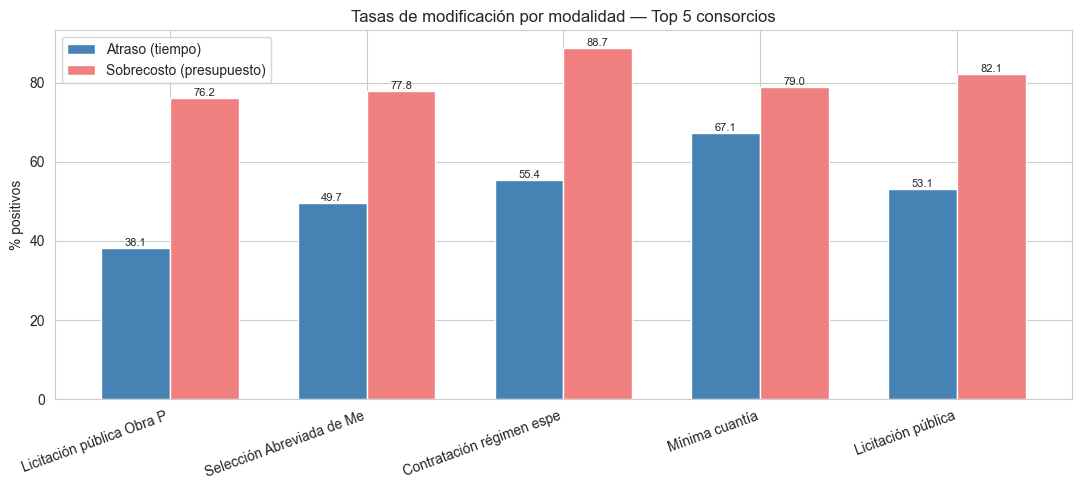

In [8]:
# Plot top 5 modalidades en consorcios + sus tasas de atraso
top5 = modal_c.head(5).index.tolist()
tasas_mod = cons[cons['modalidad_de_contratacion'].isin(top5)].groupby('modalidad_de_contratacion')[['tiempo', 'presupuesto']].mean() * 100
tasas_mod = tasas_mod.reindex(top5)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top5))
w = 0.35
ax.bar(x - w/2, tasas_mod['tiempo'], w, label='Atraso (tiempo)', color='steelblue')
ax.bar(x + w/2, tasas_mod['presupuesto'], w, label='Sobrecosto (presupuesto)', color='lightcoral')
ax.set_xticks(x)
ax.set_xticklabels([m[:25] for m in top5], rotation=20, ha='right')
ax.set_ylabel('% positivos')
ax.set_title('Tasas de modificación por modalidad — Top 5 consorcios')
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'dia_06_modalidad_consorcios.png', dpi=120, bbox_inches='tight')
plt.show()

**Hallazgo 3**: la modalidad dominante en consorcios es «Licitación pública Obra Pública» (53.6 %), seguida de «Selección Abreviada de Menor Cuantía» (29.6 %). Las tasas de modificación varían sustancialmente por modalidad, lo cual confirma que la modalidad es una variable predictiva con señal.

## 7. Distribución de los indicadores `pliego_*` (consorcios con extracción OK)

In [9]:
cons_ok = cons[cons['pliego_liquidez_min'].notna()]
print(f'Consorcios con pliego extraído OK: {len(cons_ok):,}\n')

stats = cons_ok[INDS_PLIEGO].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
stats.index = [LABELS[c] for c in stats.index]
print('Estadísticas descriptivas de indicadores extraídos:')
print(stats.round(3).to_string())

Consorcios con pliego extraído OK: 3,877

Estadísticas descriptivas de indicadores extraídos:
                          count          mean           std       min    5%   25%   50%   75%      95%           max
Liquidez mín             3877.0  2.522000e+00  8.549000e+00     0.000  1.00  1.20   1.5   2.0    5.722  4.756160e+02
Endeudamiento máx %      3840.0  4.403600e+01  2.983400e+01     0.000  0.44  0.70  60.0  70.0   70.000  9.800000e+01
Cobertura intereses mín  3653.0  3.659000e+00  2.379000e+01 -1043.910  0.27  1.00   1.5   3.0   11.000  7.766200e+02
ROE mín %                3669.0  4.114000e+00  6.978000e+00    -0.085  0.00  0.04   1.0   5.9   15.000  7.200000e+01
ROA mín %                3654.0  2.416000e+00  4.092000e+00    -0.010  0.00  0.02   1.0   3.0   10.000  4.500000e+01
Capital trabajo %        1341.0  1.391539e+08  4.944012e+09     0.000  0.10  1.00  30.0  50.0  100.000  1.810000e+11


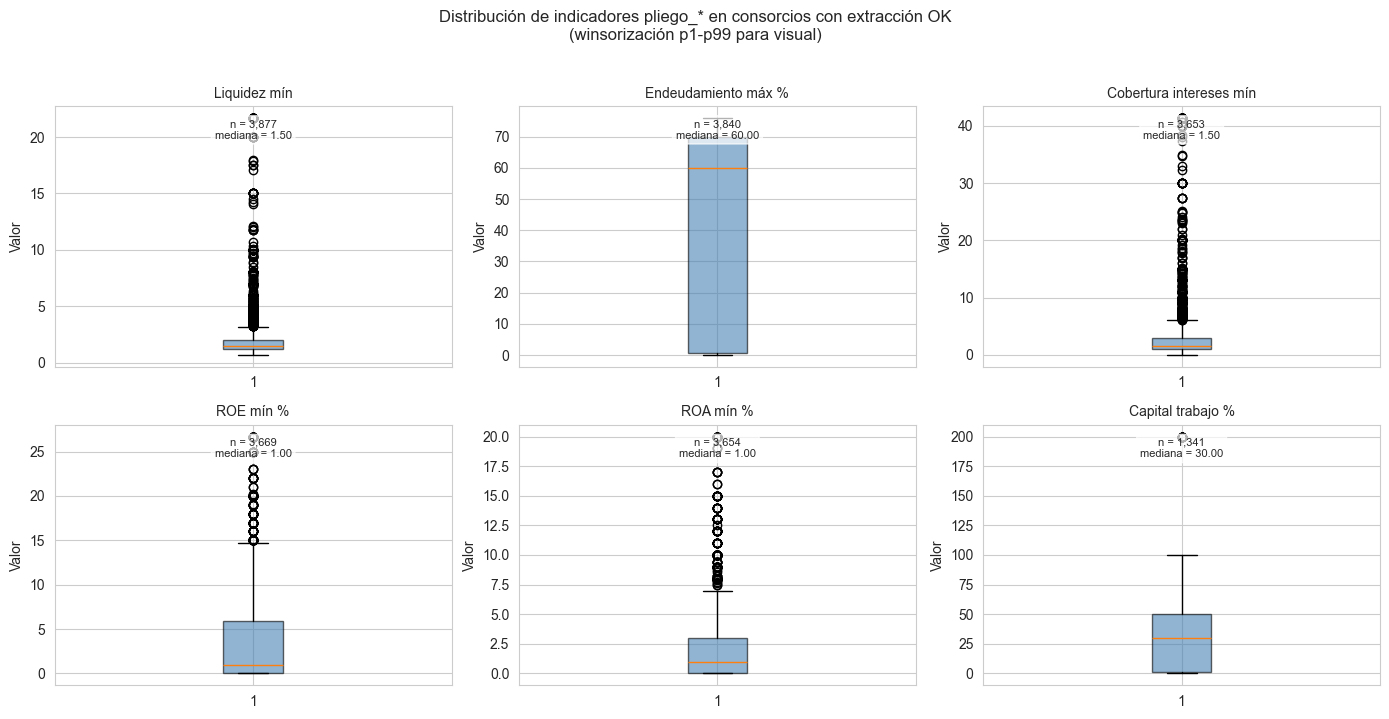

In [10]:
# Boxplots de los 6 indicadores (con winsorización p1-p99 para visual)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flatten(), INDS_PLIEGO):
    s = cons_ok[c].dropna()
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    s_clip = s.clip(lo, hi)
    ax.boxplot(s_clip, vert=True, patch_artist=True,
                boxprops={'facecolor': 'steelblue', 'alpha': 0.6})
    ax.set_title(LABELS[c], fontsize=10)
    ax.set_ylabel('Valor')
    ax.text(0.5, 0.95, f'n = {len(s):,}\nmediana = {s.median():.2f}',
             transform=ax.transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7), fontsize=8)
plt.suptitle('Distribución de indicadores pliego_* en consorcios con extracción OK\n(winsorización p1-p99 para visual)', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'dia_06_dist_indicadores.png', dpi=120, bbox_inches='tight')
plt.show()

**Hallazgo 4**: los indicadores extraídos presentan datos sucios que requieren limpieza antes de incorporarse al modelo definitivo. En particular:

- `endeudamiento_max_pct` presenta formato mixto: algunos contratos lo expresan como fracción (0.70) y otros como porcentaje (70.0).
- `capital_trabajo` y `cobertura_intereses_min` presentan outliers extremos (errores de extracción del modelo de lenguaje).

Estos casos quedan documentados como trabajo pendiente para la siguiente iteración del modelo.

## 8. ¿La extracción del pliego correlaciona con menor riesgo?

Cruce crítico: comparamos las tasas de modificación entre consorcios CON pliego extraído OK vs sin pliego extraído. Si la diferencia es alta, las variables `pliego_*` aportarían señal predictiva.

In [11]:
cons['tiene_pliego'] = cons['pliego_liquidez_min'].notna()

ct = cons.groupby('tiene_pliego')[['tiempo', 'presupuesto', 'alcance']].mean() * 100
ct.index = ['SIN pliego (n=' + f'{(~cons["tiene_pliego"]).sum():,})',
             'CON pliego (n=' + f'{cons["tiene_pliego"].sum():,})']
print('Tasas (%) por presencia de pliego extraído OK:')
print(ct.round(2).to_string())

deltas = ct.iloc[1] - ct.iloc[0]
print('\nDelta (CON − SIN) en puntos porcentuales:')
for col, d in deltas.items():
    print(f'  {col:<15} {d:>+.2f} pp')

Tasas (%) por presencia de pliego extraído OK:
                      tiempo  presupuesto  alcance
SIN pliego (n=6,752)   44.42        77.09    94.03
CON pliego (n=3,877)   45.01        79.29    92.55

Delta (CON − SIN) en puntos porcentuales:
  tiempo          +0.59 pp
  presupuesto     +2.20 pp
  alcance         -1.49 pp


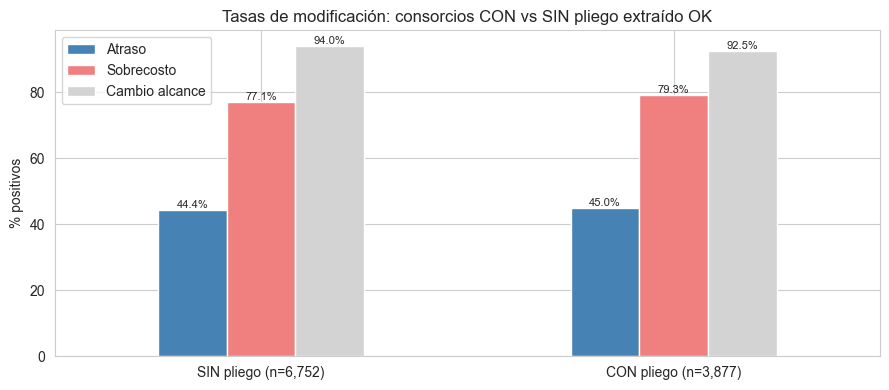

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ct.plot(kind='bar', ax=ax, color=['steelblue', 'lightcoral', 'lightgray'])
ax.set_ylabel('% positivos')
ax.set_title('Tasas de modificación: consorcios CON vs SIN pliego extraído OK')
ax.set_xticklabels(ct.index, rotation=0)
ax.legend(['Atraso', 'Sobrecosto', 'Cambio alcance'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'dia_06_pliego_vs_target.png', dpi=120, bbox_inches='tight')
plt.show()

**Hallazgo 5**: la diferencia entre los consorcios con y sin pliego extraído es marginal (menos de 1 punto porcentual en atraso y sobrecosto). Esto confirma que, en el estado actual de los datos extraídos y sin limpieza previa, las variables `pliego_*` no aportan señal predictiva significativa, lo cual es consistente con los resultados de la selección automatizada de variables realizada durante el Día 4b del sprint. Cuando se aplique una limpieza adecuada (corrección de formato mixto y winsorización de outliers), este análisis debería repetirse para verificar si emerge señal predictiva.

## 9. Top departamentos donde operan los consorcios

Top 15 departamentos por volumen de consorcios:
                               n  tasa_atraso  tasa_sobrecosto  valor_mediano
departamento                                                                 
Distrito Capital de Bogotá  3585         42.3             75.6   2.241325e+09
Valle del Cauca              751         40.3             75.1   1.122000e+09
Cundinamarca                 529         38.0             85.3   8.776199e+08
Antioquia                    517         42.6             77.2   3.003877e+09
Santander                    410         47.8             63.7   1.663819e+09
Tolima                       363         49.0             82.6   1.116368e+09
Bolívar                      361         47.6             75.3   2.201221e+09
Caldas                       337         28.8             81.0   8.518985e+08
Boyacá                       333         43.8             77.5   5.190355e+08
Norte de Santander           303         51.5             75.9   8.083838e+08
Huila           

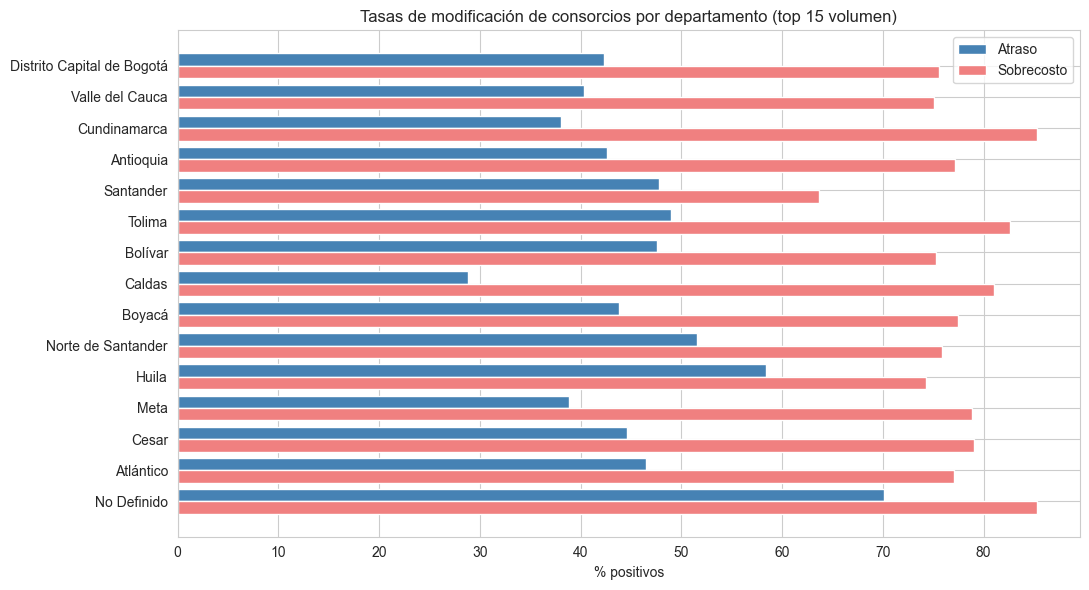

In [13]:
depto = cons.groupby('departamento').agg(
    n=('valor_del_contrato', 'size'),
    tasa_atraso=('tiempo', 'mean'),
    tasa_sobrecosto=('presupuesto', 'mean'),
    valor_mediano=('valor_del_contrato', 'median'),
).sort_values('n', ascending=False).head(15)
depto['tasa_atraso'] = (depto['tasa_atraso'] * 100).round(1)
depto['tasa_sobrecosto'] = (depto['tasa_sobrecosto'] * 100).round(1)
print('Top 15 departamentos por volumen de consorcios:')
print(depto.to_string())

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(depto))
w = 0.4
ax.barh(x - w/2, depto['tasa_atraso'], w, label='Atraso', color='steelblue')
ax.barh(x + w/2, depto['tasa_sobrecosto'], w, label='Sobrecosto', color='lightcoral')
ax.set_yticks(x)
ax.set_yticklabels(depto.index)
ax.invert_yaxis()
ax.set_xlabel('% positivos')
ax.set_title('Tasas de modificación de consorcios por departamento (top 15 volumen)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'dia_06_consorcios_por_depto.png', dpi=120, bbox_inches='tight')
plt.show()

**Hallazgo 6**: existe variabilidad geográfica significativa de las tasas de modificación entre departamentos. Esta variabilidad justifica la inclusión de la variable `departamento_freq` como predictor relevante en el modelo (efectivamente quedó dentro de las 30 variables seleccionadas tras la selección automatizada del Día 4b).

## 10. Conclusiones preliminares

El análisis cuantitativo de los consorcios al cierre del pipeline desatendido de extracción permite formular las siguientes conclusiones preliminares:

**Sobre el perfil de los consorcios**

Los consorcios representan el 22,0 % del dataset de contratos de obra (10.629 de 48.331 contratos). Concentran contratos de mayor valor (mediana de 1.542 millones COP frente a 200-300 millones en el resto del dataset), lo que confirma que la modalidad de unión empresarial se utiliza primordialmente para acceder a contratos de gran envergadura que superan la capacidad financiera individual de cada empresa.

**Sobre el riesgo contractual**

Los consorcios presentan tasas de modificación menores que los contratos no asociados a esta modalidad. La tasa de atraso es de 44,6 % en consorcios frente a 60,5 % en el resto del dataset (diferencia de 15,9 pp), y la tasa de sobrecosto es de 77,9 % frente a 83,4 % (diferencia de 5,5 pp). Esto sugiere que los consorcios, al combinar capacidades organizacionales y financieras de varias empresas, son menos propensos a requerir modificaciones contractuales durante la ejecución.

**Sobre la cobertura del pipeline de extracción**

El pipeline desatendido procesó 7.994 contratos de consorcios. De estos, 4.276 alcanzaron el estado «ok» con extracción exitosa de al menos un indicador (53,5 % del procesado, 40,2 % del universo total de consorcios). Las variables `pliego_*` quedaron con una cobertura efectiva del 36,5 % en el subconjunto de consorcios y del 8,0 % en el dataset completo.

**Sobre el aporte predictivo de los indicadores extraídos**

El análisis de cruce entre la presencia del pliego extraído y las tasas de modificación contractual muestra diferencias inferiores a 1 punto porcentual entre los consorcios con y sin pliego extraído. Esto confirma que, en el estado actual de los datos —antes de la aplicación de un proceso de limpieza específico— las variables `pliego_*` no aportan señal predictiva al modelo, hallazgo consistente con los resultados de la selección automatizada de variables del Día 4b. Se identificó que los datos extraídos presentan problemas de calidad atribuibles al proceso de extracción semántica con modelos de lenguaje: formato mixto entre fracciones y porcentajes en la variable `endeudamiento_max_pct`, y outliers extremos en `capital_trabajo` y `cobertura_intereses_min`. La aplicación de un proceso de normalización (detección automática de formato + winsorización de outliers a percentiles 1 y 99) constituye un trabajo pendiente que podría reabrir la utilidad de estas variables.

**Sobre la variabilidad geográfica**

Existe variabilidad significativa entre departamentos en las tasas de modificación contractual de los consorcios, lo cual justifica la inclusión de la variable `departamento_freq` en el modelo predictivo, y abre la puerta a futuros análisis territoriales más detallados.

**Implicaciones para el modelo predictivo**

Las conclusiones anteriores sugieren tres líneas de trabajo para el periodo restante del proyecto: (i) aplicar la calibración fina de hiperparámetros sobre el modelo multi-target ya entrenado, conforme al plan original; (ii) implementar un script de normalización de los indicadores `pliego_*` y verificar si su aporte predictivo emerge tras la limpieza; (iii) explorar la viabilidad de entrenar un modelo especializado únicamente sobre el subconjunto de consorcios, dado que sus características diferenciales (mayor valor, menor tasa de modificación) podrían beneficiarse de un modelo dedicado con mayor precisión sobre este nicho específico de contratación.